> # SECTION -4

## Run quantum circuits

<h4>

--- 
- Execution modes

- **Execution on real hardware**

---

</h4>
REFERENCES: 

https://quantum.cloud.ibm.com/docs/en/guides/hello-world



--- 
> ## Execution on real hardware
--- 
## IBM Quantum Compute client to run jobs on quantum hardware: **qiskit-ibm-runtime**



```
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    # For `token`, use the 44-character API_KEY you created
    # and saved from the IBM Quantum Platform Home dashboard
    token="<your-api-key>",
    instance="<CRN>", # Optional
)
```

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()

In [3]:
#service.active_instance()

In [4]:
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

In [5]:
backend = service.least_busy(simulator=False, operational=True)
backend.backend_name

'ibm_marrakesh'

In [6]:
# Uncomment the next line if you want to use a simulator:
from qiskit_ibm_runtime.fake_provider import FakeBelemV2

backend = FakeBelemV2()

In [7]:
backend.backend_name

'fake_belem'


---
## 4 steps : To write a quantum program using Qiskit patterns 
---

1. Map the problem to a quantum-native format.

2. Optimize the circuits and operators.

3. Execute using a quantum primitive function.

4. Analyze the results.

> # STEP1: Map the problem to a quantum-native format

## Bit ordering in Qiskit:

Consider a set of n bits (or qubits), 
LSb 0 bit numbering 

each bit 0 -----> n-1 

Circuit diagram, :
- qubit 0 is the topmost qubit, and 
- qubit n−1 the bottommost qubit

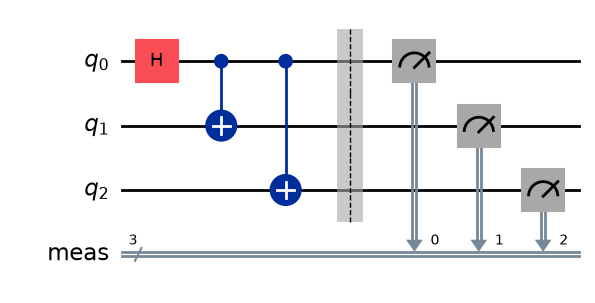

In [8]:
# Create 3-qubit GHZ state
from qiskit import QuantumCircuit, QuantumRegister
qc = QuantumCircuit(3)

qc.h(0)

qc.cx(0,1)
qc.cx(0,2)

qc.measure_all()

qc.draw("mpl")

**quantum circuit** ---->  native format to  represent quantum instructions

**operators**.      ---->  represent the observables to be measured
## 2 ways to return data:

1. ### **sampling output** for a set of qubits you choose to measure, 

2. ### obtain the **expectation value** of an observable.

> # STEP 2 :Optimize the circuits and operators

**On a device execution:** 

- optimize the set of instructions  

- minimize the overall depth of the circuit

Reason: to obtain best results by reducing the effects of error and noise.

**Backend device selection** ,consider 

- Device Instruction Set Architecture (ISA) 

- device's basis gates and qubit connectivity.

In [9]:
backend

In [10]:
backend.backend_name

'fake_belem'

In [11]:
backend.num_qubits

5

> # Convert to an ISA circuit

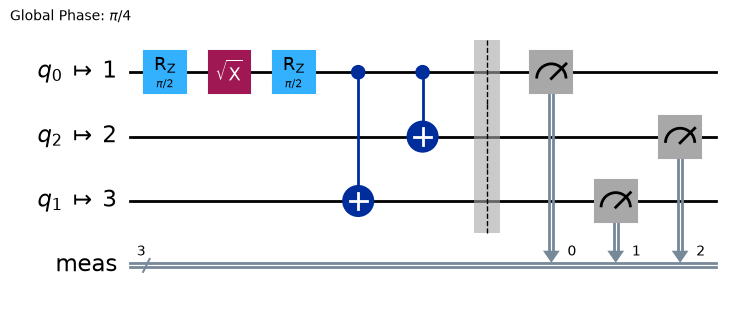

In [12]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

isa_circuit = pm.run(qc)

isa_circuit.draw("mpl")

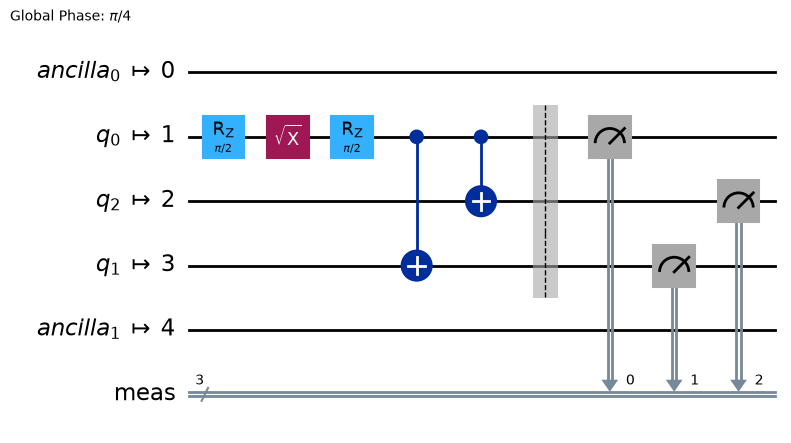

In [13]:
isa_circuit.draw("mpl",idle_wires=True)

# Step 3. Execute using the quantum primitives

2 primitives 

1. sampler
2. Estimator

> # Sampler

 #### Can be used to get data from a quantum computer

># Construct the Sampler instance

In [14]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [15]:


job = sampler.run([(isa_circuit)])

print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 0a162555-4bb0-46a4-b2e0-3b0a28c0943b
>>> Job Status: JobStatus.RUNNING


In [16]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: JobStatus.RUNNING


> # Step 4. Analyze the results

<h3>
To obtain the results from Sampler, 

use the **PubResult.data.meas.get_counts()** function, 


return a dict of measurements in the form of bitstrings as keys and counts as their corresponding values
</h3>

In [17]:
result = job.result()
data= result[0].data
counts_result=data.meas.get_counts()
print(counts_result)

{'000': 517, '111': 406, '101': 26, '011': 24, '110': 25, '001': 9, '010': 12, '100': 5}


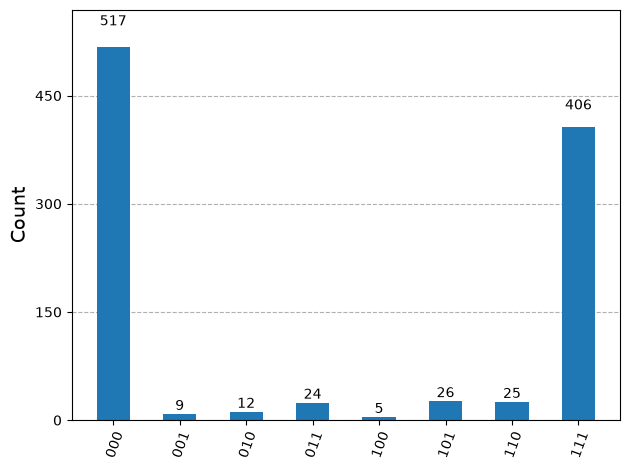

In [18]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_result)

---
> # Estimator

#### Can estimate the value of the observable by using the Estimator class

---

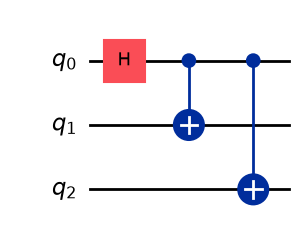

In [19]:
# Create 3-qubit GHZ state

qc = QuantumCircuit(3)

qc.h(0)

qc.cx(0,1)
qc.cx(0,2)

qc.draw("mpl")

># creates 4 three-qubit Pauli operators

#### IZZ operator is a shorthand for the tensor product  I⊗Z⊗Z, 

- I on qubit 2 and 
- Z on qubit 1 
- Z on qubit 0 

- Expectation values like this are also typically written as ⟨I2 Z1 Z0⟩

In [20]:
from qiskit.quantum_info import SparsePauliOp

observables_labels = ["ZZZ","IZZ","ZIZ","ZZI"]

observables = [SparsePauliOp(label) for label in observables_labels]

In [21]:
observables

[SparsePauliOp(['ZZZ'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['IZZ'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['ZIZ'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['ZZI'],
               coeffs=[1.+0.j])]

># Construct the Estimator instance

In [22]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

> # Convert to an ISA circuit

In [23]:
# Convert to an ISA circuit and layout-mapped observables

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

isa_circuit = pm.run(qc)

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against 4 different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 140c700b-e472-45f6-b9fb-d11367eb1c99
>>> Job Status: JobStatus.RUNNING


In [24]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: JobStatus.RUNNING


In [25]:

job_result = job.result() #result of the entire submission,submitted one Pub

pub_result = job.result()[0]      #result from single pub, which has observables,contains information of all 

> # Step 4. Analyze the results
<h3>
The expectation values and standard deviations for the observables specified to Estimator are accessed job result's 

1. PubResult.data.evs 

2. PubResult.data.stds 
</h3>

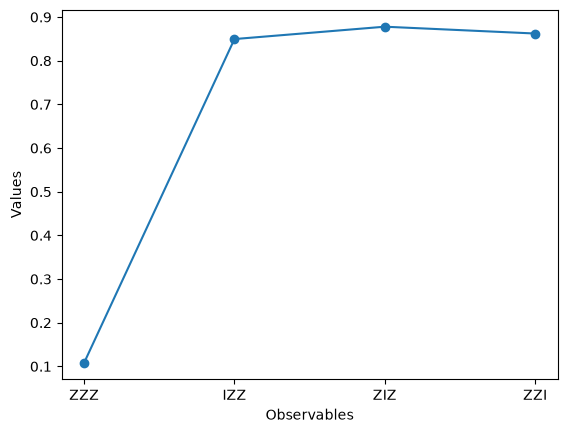

In [26]:
from matplotlib import pyplot as plt
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [27]:
values

array([0.10839844, 0.84960938, 0.87792969, 0.86230469])

In [28]:
errors

array([0.01553293, 0.00824082, 0.00748109, 0.00791234])

Estimator: Runs the circuit and computes 

⟨ψ∣O∣ψ⟩ directly — no manual measurement post-processing needed.

![](Zgate.png)

![](GHZ_1.png)

![](GHZ_exp.png)

># Using statevector Estimator

In [29]:
from qiskit.primitives import StatevectorEstimator
estimator = StatevectorEstimator()
job = estimator.run([(qc, observables)])
result = job.result()

print(result[0].data.evs)

[0. 1. 1. 1.]


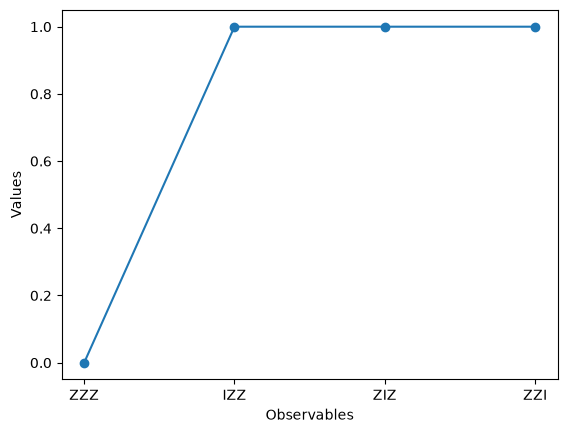

In [30]:

values = result[0].data.evs

errors = result[0].data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [31]:
values

array([0., 1., 1., 1.])

In [32]:
errors

array([0., 0., 0., 0.])